# Training Pipeline

## Overview

This notebook documents the full training pipeline for a YOLO-based
Fair Value Gap (FVG) detector trained on NQ futures (Micro E-mini
Nasdaq-100) chart screenshots.

Four models were trained and compared across two architectures
(YOLOv11 and YOLO26) and two scales (nano and medium):

| Model    | Epochs | mAP@50 | mAP@50-95 | Precision | Recall | F1    |
|----------|--------|--------|-----------|-----------|--------|-------|
| YOLO26n  | 100    | 87.3%  | 49.8%     | 83.6%     | 81.9%  | -     |
| YOLOv11n | 100    | 91.5%  | 54.3%     | 87.5%     | 88.6%  | -     |
| YOLOv11m | 100    | 93.4%  | 57.0%     | 90.1%     | 88.8%  | 85.6% |
| YOLO26m  | 80     | 93.3%  | 56.7%     | 86.7%     | 91.9%  | 86.6% |

**Final selected model: YOLO26m** — chosen for superior mAP@50 and
Recall on the unseen test set (92.3% mAP@50), and better
generalization gap between validation and test compared to YOLOv11m.

### What is an FVG?
A Fair Value Gap (FVG) is an ICT (Inner Circle Trader) concept that
identifies a 3-candle price inefficiency where a gap exists between
the wick of candle 1 and the wick of candle 3. Two classes are detected:
- `bullish_fvg` — gap created during an upward impulse move
- `bearish_fvg` — gap created during a downward impulse move

### Dataset
- **Instrument:** NQ1! (Micro E-mini Nasdaq-100 Futures)
- **Timeframes:** 1m, 5m
- **Total images:** 295 screenshots containing around 2500 combined class examples
- **Split:** 70/15/15 train/val/test
- **Annotated on:** Roboflow

## 2. Setup & Imports

In [123]:
import os
from pathlib import Path

In [124]:
project_root = Path.cwd().parent

In [125]:
project_root

WindowsPath('E:/ml projects/trading-cv-fvg')

## 3. Dataset

In [ ]:
data_path_root = os.path.join(project_root, 'data\dataset')
data_path_root

In [ ]:
data_path_v11 = os.path.join(data_path_root, 'My-First-Project.v4i.yolov11')
data_path_v11

### Labeled Data Sample

In [134]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


In [135]:
img_dir = os.path.join(data_path_v11,'train\images')
label_dir = os.path.join(data_path_v11,'train\labels')

In [136]:
def plot_labeled_examples(img_path, label_path):


    img = mpimg.imread(img_path)
    h, w = img.shape[:2]


    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    ax.imshow(img, interpolation='none')

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                cls, cx, cy, bw, bh = map(float, line.strip().split())

                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                box_w = bw * w
                box_h = bh * h

                color = 'red' if cls == 0 else 'lime'
                label = 'bearish' if cls == 0 else 'bullish'

                rect = plt.Rectangle(
                    (x1, y1), box_w, box_h,
                    linewidth=3,
                    edgecolor=color,
                    facecolor=color,
                    alpha=0.3
                )
                ax.add_patch(rect)
                ax.text(x1, y1-2, label, color=color,
                       fontsize=7, fontweight='bold',
                       bbox=dict(facecolor='white', alpha=0.7, pad=1))


    ax.axis('off')
    plt.tight_layout()
    plt.show()



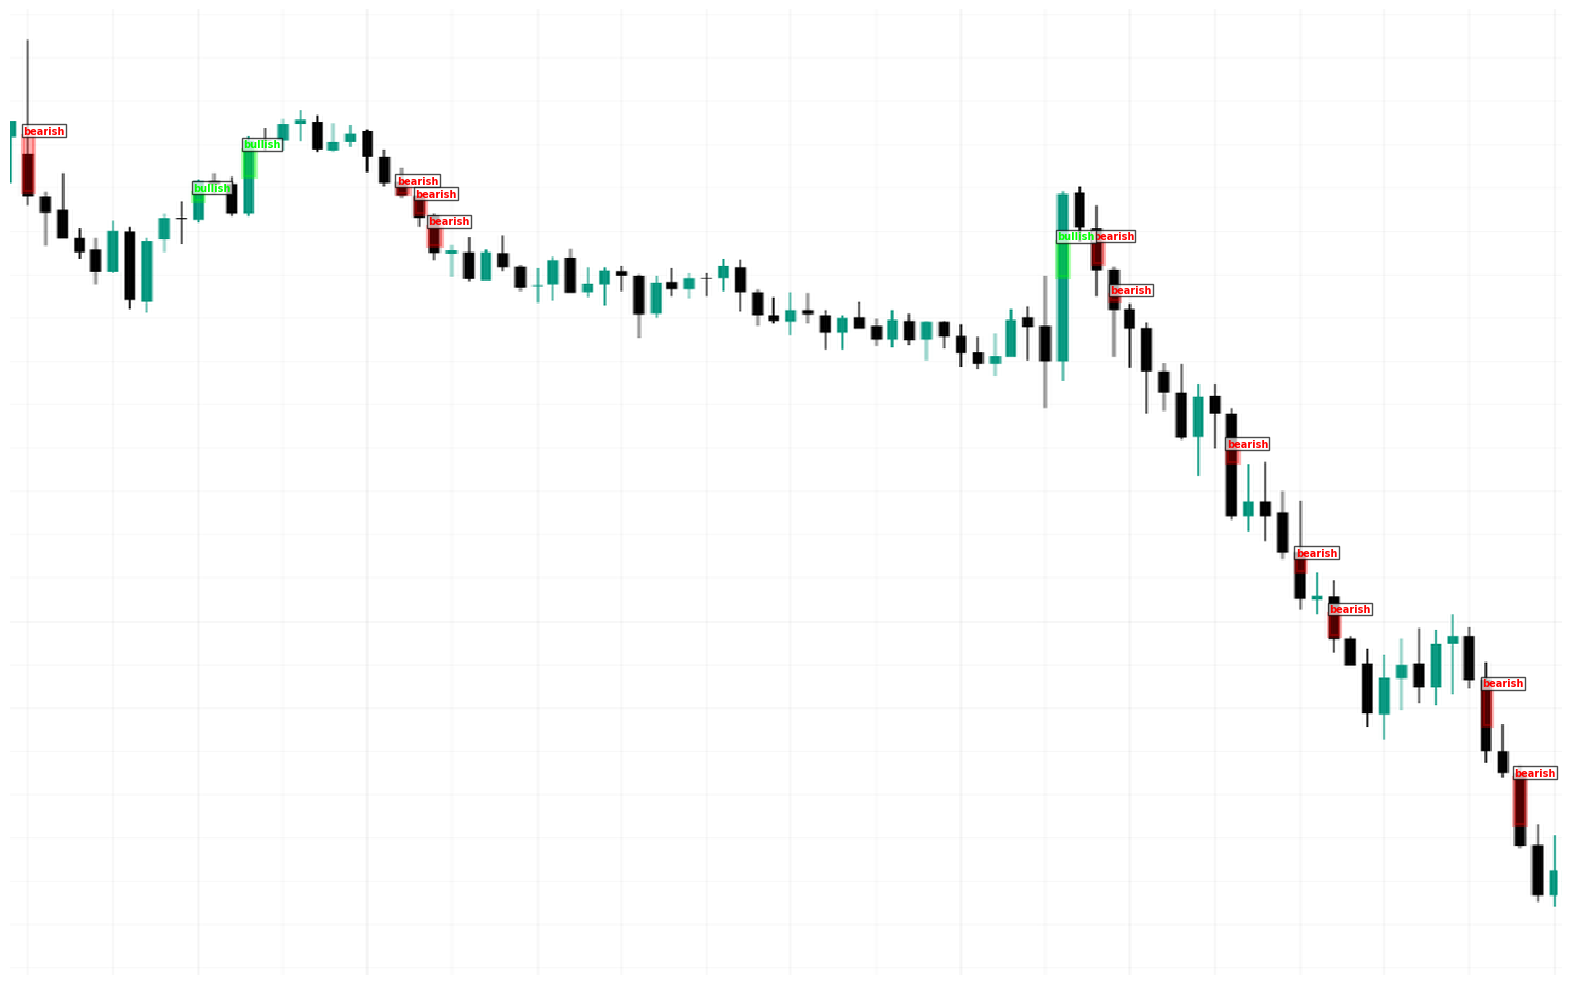

In [141]:
import os

def find_label_for_image(original_name, label_dir):
    """Find roboflow label file for an original image name"""
    base_name = os.path.splitext(original_name)[0]

    for label_file in os.listdir(label_dir):
        # Match exact base name followed by _png.rf
        if label_file.startswith(base_name + '_png.rf'):
            return os.path.join(label_dir, label_file)
    return None


label_dir = os.path.join(project_root, 'data', 'dataset', 'My-First-Project.v4i.yolov11', 'train', 'labels')
label_path = find_label_for_image('1min-NQ-5.png', label_dir)
img_path = os.path.join(project_root, 'data', 'data-resized', '1min', '1min-NQ-5.png')


plot_labeled_examples(img_path, label_path)

## 4. Model Training

In [67]:
from ultralytics import YOLO


# Load model
# model = YOLO('yolo11n.pt')
# model = YOLO('yolo11m.pt')
# model = YOLO('yolo26n.pt')
model = YOLO('yolo26m.pt')


In [ ]:
# Train with 100 epochs
results = model.train(
    data=data_path_v11,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    optimizer='auto',
    pretrained=True,
    project=os.path.join(project_root, 'models'),
    name='fvg_detector',
    verbose=True
)

## 5. Evaluation

In [ ]:
model_path_root = os.path.join(project_root, 'models')


In [ ]:
model_path_root

In [167]:
import pandas as pd

def display_results(model_path_base, nxt_path):
    # validation results of the best model
    model = YOLO(os.path.join(model_path_base, nxt_path,'weights','best.pt'))
    metrics = model.val()

    print("="*45)
    print(f"{'VALIDATION METRICS':^45}")
    print("="*45)
    print(f"{'mAP@50':<20} {metrics.box.map50*100:.1f}%")
    print(f"{'mAP@50-95':<20} {metrics.box.map*100:.1f}%")
    print(f"{'Precision':<20} {metrics.box.mp*100:.1f}%")
    print(f"{'Recall':<20} {metrics.box.mr*100:.1f}%")
    f1 = 2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr)
    print(f"{'F1':<20} {f1*100:.1f}%")
    print("="*45)

    # training results
    img = mpimg.imread(os.path.join(model_path_base, nxt_path, 'results.png'))
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    ax.imshow(img, interpolation='none')
    plt.show()

### YOLO V11 nano

Ultralytics 8.4.64  Python-3.10.11 torch-2.12.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 158.010.2 MB/s, size: 24.2 KB)
val: Scanning E:\ml projects\trading-cv-fvg\data\dataset\My-First-Project.v4i.yolov11\valid\labels.cache... 44 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3s/it 4.0s2.8s
                   all         44        549      0.875      0.886      0.915      0.543
           bearish_fvg         43        285      0.876      0.868      0.917      0.541
           bullish_fvg         42        264      0.873      0.905      0.912      0.545
Speed: 2.1ms preprocess, 75.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to E:\ml projects\trading-cv-fvg\runs\detect\val-8
             VALIDATIO

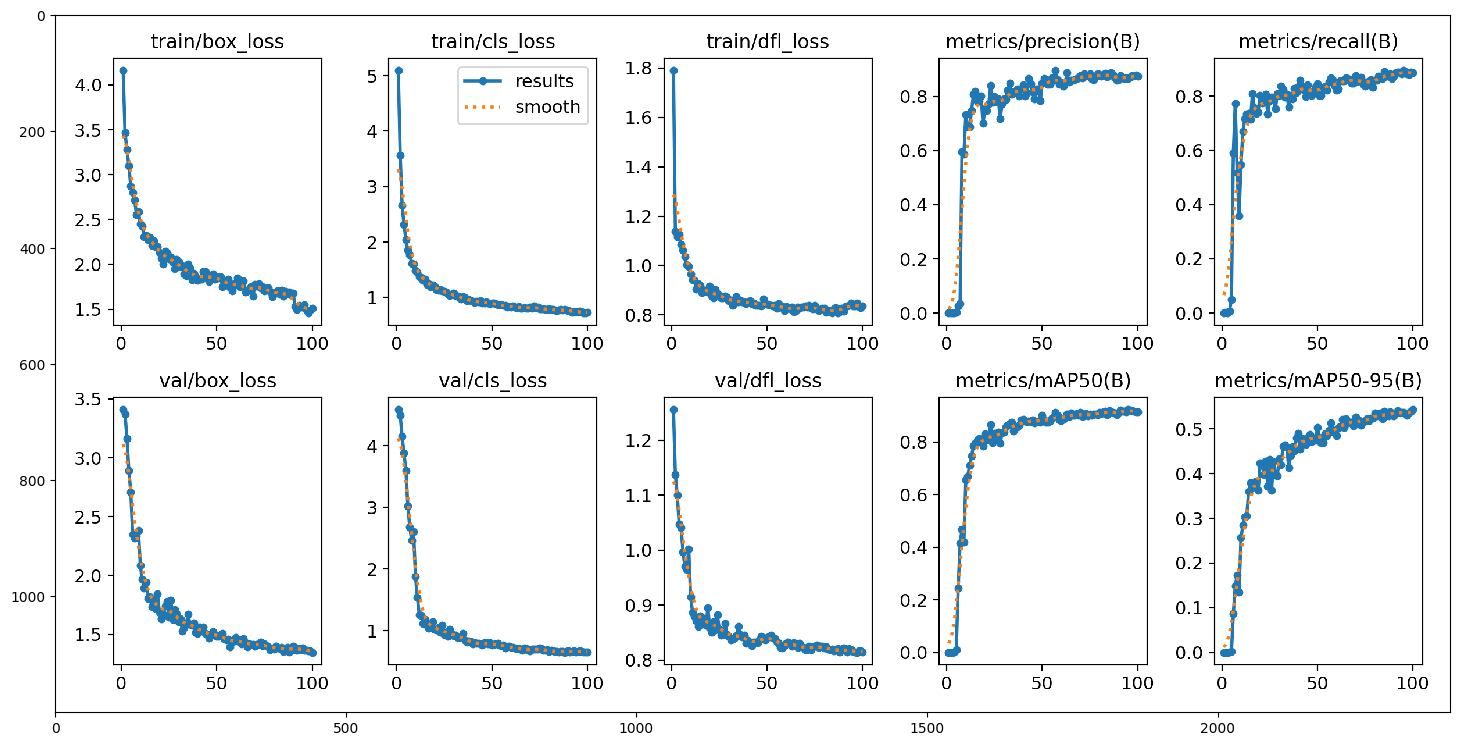

In [168]:
display_results(model_path_root, 'fvg_detector')

### YOLO V11 medium

Ultralytics 8.4.64  Python-3.10.11 torch-2.12.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
YOLO11m summary (fused): 126 layers, 20,031,574 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 285.351.7 MB/s, size: 25.9 KB)
val: Scanning E:\ml projects\trading-cv-fvg\data\dataset\My-First-Project.v4i.yolov11\valid\labels.cache... 44 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 6.6s/it 19.9s<14.6s
                   all         44        549      0.889      0.889      0.934      0.571
           bearish_fvg         43        285      0.898        0.9       0.94      0.567
           bullish_fvg         42        264      0.879      0.878      0.928      0.575
Speed: 1.4ms preprocess, 432.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to E:\ml projects\trading-cv-fvg\runs\detect\val-9
             VAL

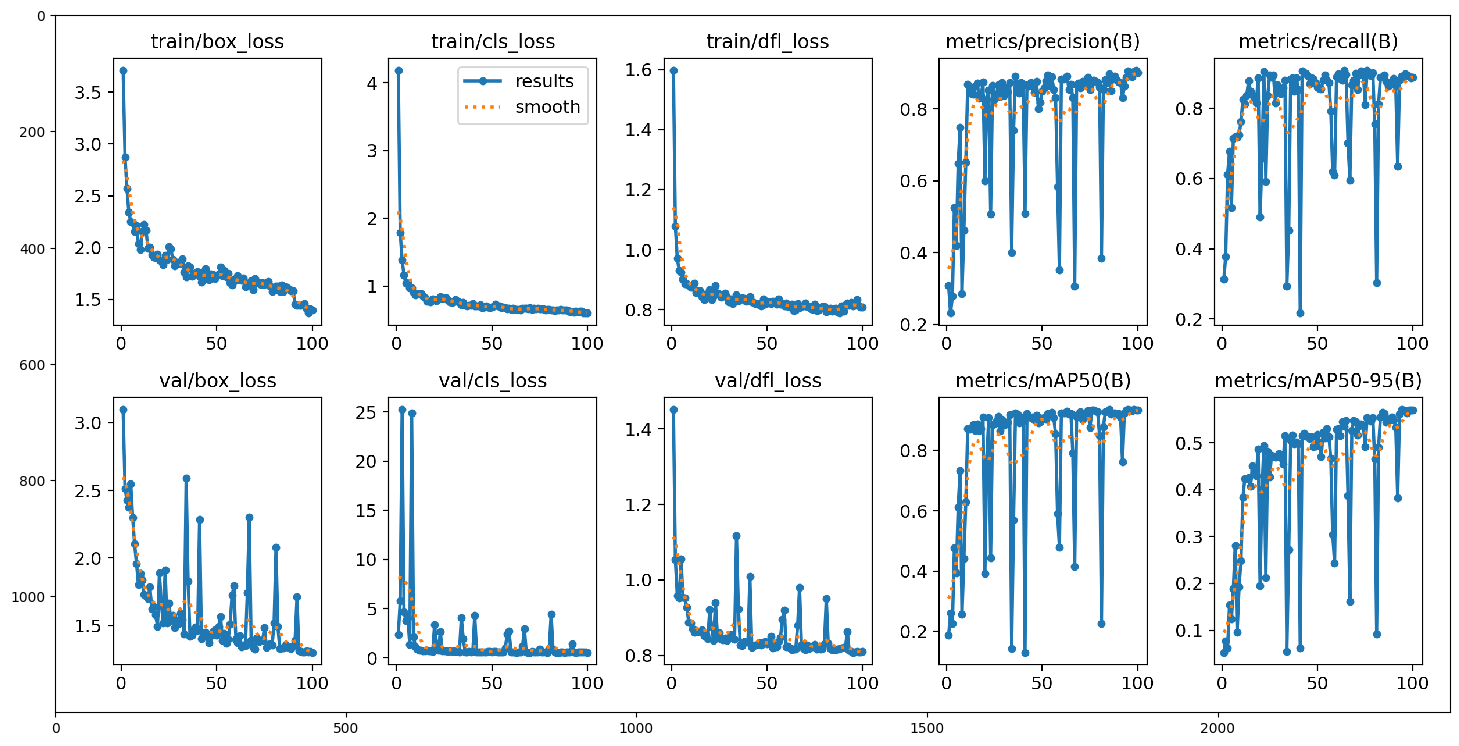

In [169]:
display_results(model_path_root, 'fvg_detector-2')

## Observations

Medium model is better that the nano version across all metrics

### Yolo v26 nano

Ultralytics 8.4.64  Python-3.10.11 torch-2.12.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 275.122.6 MB/s, size: 23.9 KB)
val: Scanning E:\ml projects\trading-cv-fvg\data\dataset\My-First-Project.v4i.yolov11\valid\labels.cache... 44 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3s/it 3.8s2.7s
                   all         44        549      0.804      0.853       0.87      0.503
           bearish_fvg         43        285      0.831      0.835      0.881      0.507
           bullish_fvg         42        264      0.777      0.872      0.858      0.499
Speed: 1.3ms preprocess, 73.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to E:\ml projects\trading-cv-fvg\runs\detect\val-10
             VALIDATI

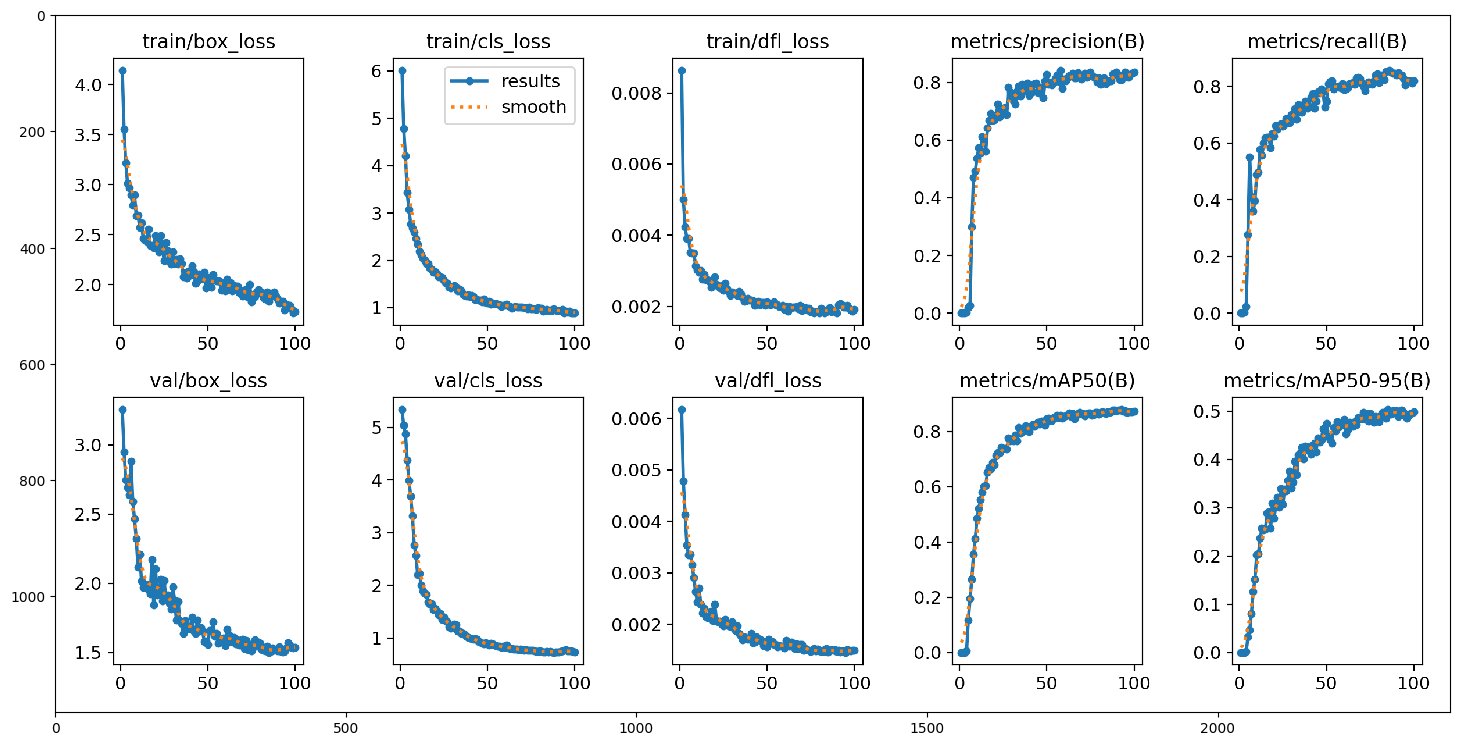

In [170]:
display_results(model_path_root, 'fvg_detector-3')

### Yolo v26 medium

Ultralytics 8.4.64  Python-3.10.11 torch-2.12.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
YOLO26m summary (fused): 132 layers, 20,350,994 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 196.924.1 MB/s, size: 24.7 KB)
val: Scanning E:\ml projects\trading-cv-fvg\data\dataset\My-First-Project.v4i.yolov11\valid\labels.cache... 44 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 6.2s/it 18.6s<13.2s
                   all         44        549       0.89      0.909      0.932      0.574
           bearish_fvg         43        285      0.904      0.897      0.936      0.576
           bullish_fvg         42        264      0.876       0.92      0.927      0.573
Speed: 2.4ms preprocess, 409.2ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to E:\ml projects\trading-cv-fvg\runs\detect\val-11
             VA

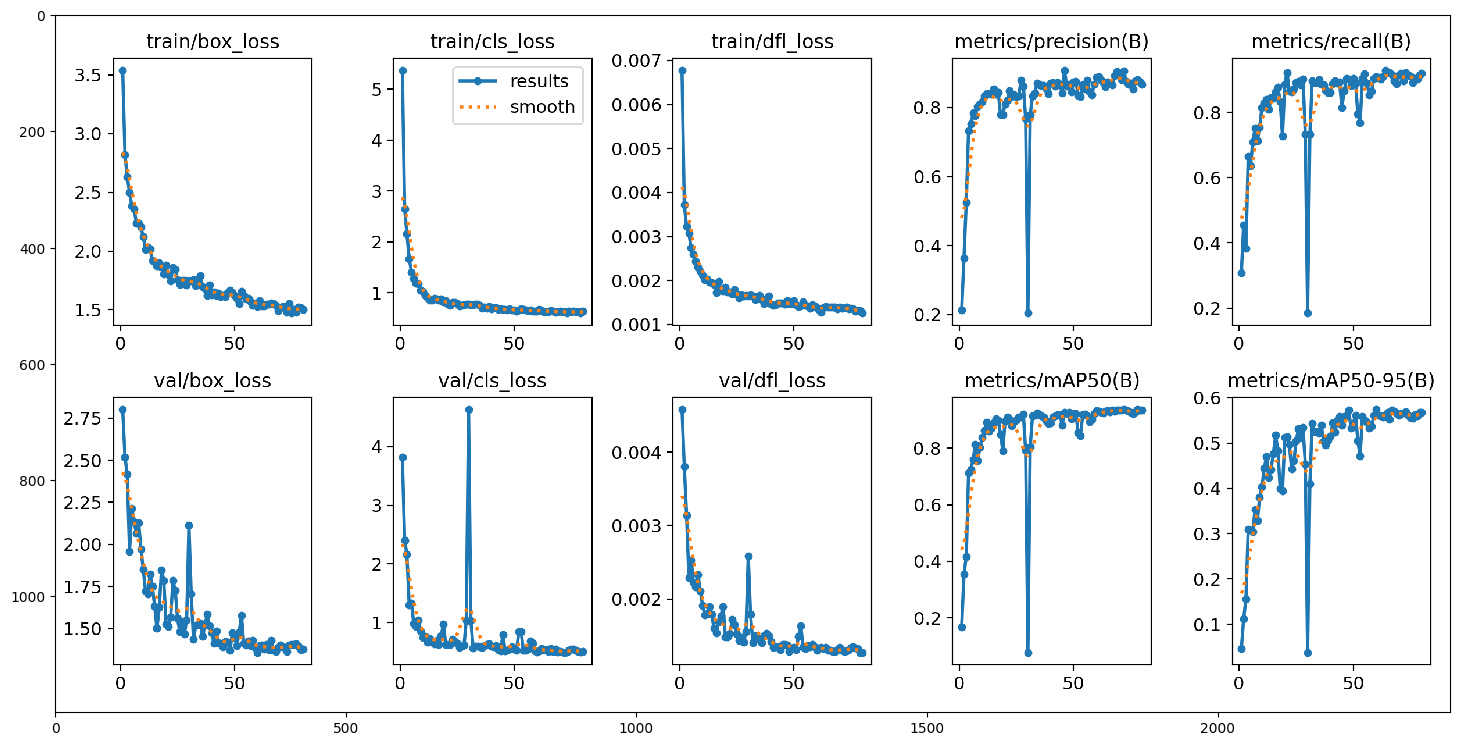

In [171]:
display_results(model_path_root, 'fvg_detector-4')

### Observations
Medium model is better that the nano version across all metrics

## Model Selection

At this point we have two models to choose from. To select the best model we'll test them on the test set.

### Test Set EVAL

In [ ]:
model_path_root

### Test set eval for Yolov11m

In [ ]:
data_path_v11

In [175]:
from ultralytics import YOLO

model = YOLO(os.path.join(model_path_root, r'fvg_detector-2/weights/best.pt'))

# Test set evaluation
test_results = model.val(
    data= os.path.join(data_path_v11,'data.yaml'),
    split='test',
    plots=True
)

print("\n" + "="*45)
print(f"{'TEST SET METRICS':^45}")
print("="*45)
print(f"{'mAP@50':<20} {test_results.box.map50*100:.1f}%")
print(f"{'mAP@50-95':<20} {test_results.box.map*100:.1f}%")
print(f"{'Precision':<20} {test_results.box.mp*100:.1f}%")
print(f"{'Recall':<20} {test_results.box.mr*100:.1f}%")
f1 = 2 * (test_results.box.mp * test_results.box.mr) / (test_results.box.mp + test_results.box.mr)
print(f"{'F1':<20} {f1*100:.1f}%")
print("="*45)

Ultralytics 8.4.64  Python-3.10.11 torch-2.12.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
YOLO11m summary (fused): 126 layers, 20,031,574 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 179.88.6 MB/s, size: 23.3 KB)
val: Scanning E:\ml projects\trading-cv-fvg\data\dataset\My-First-Project.v4i.yolov11\test\labels.cache... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.9s/it 17.6s<12.7s
                   all         44        578      0.858      0.853      0.905      0.558
           bearish_fvg         43        235      0.825      0.872      0.902      0.546
           bullish_fvg         44        343      0.891      0.834      0.909       0.57
Speed: 1.2ms preprocess, 383.6ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to E:\ml projects\trading-cv-fvg\runs\detect\val-12

              TE

### Test set eval for Yolov26m

In [176]:
from ultralytics import YOLO

model = YOLO(os.path.join(model_path_root, r'fvg_detector-4/weights/best.pt'))

# Test set evaluation
test_results = model.val(
    data= os.path.join(data_path_v11,'data.yaml'),
    split='test',
    plots=True
)

print("\n" + "="*45)
print(f"{'TEST SET METRICS':^45}")
print("="*45)
print(f"{'mAP@50':<20} {test_results.box.map50*100:.1f}%")
print(f"{'mAP@50-95':<20} {test_results.box.map*100:.1f}%")
print(f"{'Precision':<20} {test_results.box.mp*100:.1f}%")
print(f"{'Recall':<20} {test_results.box.mr*100:.1f}%")
f1 = 2 * (test_results.box.mp * test_results.box.mr) / (test_results.box.mp + test_results.box.mr)
print(f"{'F1':<20} {f1*100:.1f}%")
print("="*45)

Ultralytics 8.4.64  Python-3.10.11 torch-2.12.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
YOLO26m summary (fused): 132 layers, 20,350,994 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 220.117.7 MB/s, size: 24.6 KB)
val: Scanning E:\ml projects\trading-cv-fvg\data\dataset\My-First-Project.v4i.yolov11\test\labels.cache... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 6.1s/it 18.4s<13.2s
                   all         44        578      0.839      0.894      0.923      0.582
           bearish_fvg         43        235      0.809      0.883       0.92      0.587
           bullish_fvg         44        343      0.869      0.905      0.927      0.578
Speed: 2.5ms preprocess, 405.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to E:\ml projects\trading-cv-fvg\runs\detect\val-13

              T

## 6. Conclusion

V26 shows better generalization on the test set compared to V11, which appears to be slightly overfitted to the training data. Across most evaluation metrics, V26 outperforms V11, with the only exception being precision. Overall, given the available dataset size and performance across metrics, YOLO V26 is the more suitable model for this computer vision task.
